# Assembling the Spatial Transcriptomics Datasets

## Overview

This notebook serves as the complete data ingestion pipeline for the course. It automatically downloads, subsets, and prepares the public datasets required for the downstream exercises.

The course focuses on paired spatial assays from the **Human Colon Cancer (Sample P2 CRC)** dataset:

* **Visium HD:** Sequencing-based spatial transcriptomics (binned at 16µm).
* **Xenium In Situ:** Imaging-based spatial transcriptomics.
* **Chromium (scRNA-seq):** Count matrix used as a single-cell reference during deconvolution and annotation.

To prepare these massive datasets for the upcoming exercises without overwhelming local hardware, this pipeline executes three main tasks:

* **Downloading:** Raw inputs (like massive FASTQ files) are intentionally skipped. We start directly from the public processed outputs.
* **Subsetting:** Because the Visium HD and Xenium samples are serial sections (adjacent slices), they represent approximately matching tissue regions rather than exact pixel-by-pixel registrations. This notebook generates overview plots (saved to `data/prep_reports/`) to visually confirm and adjust the Region of Interest (ROI) coordinates.
* **Compacting:** The final, heavily subsetted objects and their respective analysis reports are assembled into a compact course folder (`data/Human_Colon_Cancer_P2/`) for easy distribution.

## Environment setup

### Loading libraries

In [1]:
# Suppress warnings and messages to keep the notebook output clean
suppressPackageStartupMessages(suppressWarnings({
  # Core infrastructure & single-cell utilities
  library(HDF5Array)
  library(scuttle)
  library(DropletUtils)

  # Spatial object frameworks & data parsers
  library(SpatialExperiment)
  library(SpatialFeatureExperiment)
  library(VisiumIO)

  # Visualization
  library(ggplot2)
  library(ggspavis)
  library(Voyager)
}))

### Helper functions & directory setup

To keep this notebook clean and focused on data manipulation, all utility functions for data ingestion have been abstracted into an external script (`scripts/data_prep_helpers.R`).

This sourced script provides:

* **Path Resolution:** Dynamically finds the project root and builds the necessary `data/` subdirectories.
* **Resilient Downloading:** Advanced wrappers (like `download_if_missing_or_incomplete`) that utilize `curl` to resume broken downloads for massive datasets.
* **Extraction:** Safe wrappers for extracting `.tar.gz` and `.zip` files without overwriting existing data.
* **Spatial Utilities:** Functions like `subset_by_roi()` to mathematically crop `SpatialExperiment` objects based on physical coordinate bounding boxes.

In [2]:
# Load the helper functions into the environment, the Jupyter R kernel 
# is executing from the root of the repository
source("scripts/data_prep_helpers.R")

## Download public datasets

In this section, we retrieve the publicly available processed outputs directly from the [10x Genomics servers](https://www.10xgenomics.com/datasets). By using our custom download helpers, we ensure that interrupted downloads can be safely resumed without starting over.

### Visium HD (P2 CRC)

We begin by fetching the Visium HD outputs for the Human Colon Cancer (P2) sample. This includes the high-resolution binned count matrices, spatial imaging metadata, and Space Ranger run summaries. 

> **Note on file sizes:** The `binned_outputs.tar.gz` archive is exceptionally large (~15.8 GB). Our helper function verifies the exact byte-size (15,886,359,364 bytes) to guarantee the archive isn't corrupted before we attempt to extract it.

In [3]:
# Define the base URL for the 10x Genomics public dataset repository
visium_base <- "https://cf.10xgenomics.com/samples/spatial-exp/3.0.0/Visium_HD_Human_Colon_Cancer_P2"

# List the specific processed output files we need for downstream analysis
visium_files <- c(
  binned_outputs = "Visium_HD_Human_Colon_Cancer_P2_binned_outputs.tar.gz", # ~14.7 GB count matrices
  spatial =        "Visium_HD_Human_Colon_Cancer_P2_spatial.tar.gz",        # Spatial imaging metadata
  metrics =        "Visium_HD_Human_Colon_Cancer_P2_metrics_summary.csv",   # QC metrics
  web_summary =    "Visium_HD_Human_Colon_Cancer_P2_web_summary.html",      # Interactive report
  feature_slice =  "Visium_HD_Human_Colon_Cancer_P2_feature_slice.h5"       # HDF5 spatial slice data
)

# Set strict byte-size expectations for massive files to prevent silent corruption
# (Smaller files are left as NA_real_ so they skip the strict size check)
visium_expected_sizes <- c(
  binned_outputs = 15886359364, 
  spatial = NA_real_, 
  metrics = NA_real_, 
  web_summary = NA_real_, 
  feature_slice = NA_real_)

In [4]:
# Iterate over the files and download them securely to the 'data/raw/' directory
for (nm in names(visium_files)) {
  f <- visium_files[[nm]]
  
  download_if_missing_or_incomplete(
    url = file.path(visium_base, f), 
    destfile = data_path("raw", f), 
    expected_size = unname(visium_expected_sizes[[nm]]))
}

Downloading/resuming: Visium_HD_Human_Colon_Cancer_P2_binned_outputs.tar.gz

Downloading/resuming: Visium_HD_Human_Colon_Cancer_P2_spatial.tar.gz

Downloading/resuming: Visium_HD_Human_Colon_Cancer_P2_metrics_summary.csv

Downloading/resuming: Visium_HD_Human_Colon_Cancer_P2_web_summary.html

Downloading/resuming: Visium_HD_Human_Colon_Cancer_P2_feature_slice.h5



### Xenium In Situ (P2 CRC)

Next, we download the Xenium imaging-based outputs. These files are also large (the output ZIP is ~14.7 GB and the H&E TIFF is ~6.4 GB). To ensure these massive files download successfully without losing progress on connection drops, we again rely on our resilient download helper.

In [5]:
# Define the base URL for the 10x Genomics Xenium repository
xenium_base <- "https://cf.10xgenomics.com/samples/xenium/2.0.0/Xenium_V1_Human_Colon_Cancer_P2_CRC_Add_on_FFPE"

# List the required Xenium files (gene panel metadata, morphology images, and the main outputs zip)
xenium_files <- c(
  gene_panel = "Xenium_V1_Human_Colon_Cancer_P2_CRC_Add_on_FFPE_gene_panel.json", 
  he_image = "Xenium_V1_Human_Colon_Cancer_P2_CRC_Add_on_FFPE_he_image.ome.tif", 
  he_alignment = "Xenium_V1_Human_Colon_Cancer_P2_CRC_Add_on_FFPE_he_imagealignment.csv", 
  analysis_summary = "Xenium_V1_Human_Colon_Cancer_P2_CRC_Add_on_FFPE_analysis_summary.html", 
  outs = "Xenium_V1_Human_Colon_Cancer_P2_CRC_Add_on_FFPE_outs.zip")

In [6]:
# Iterate through the files and download them securely using the resilient curl helper
for (f in xenium_files) {
  download_if_missing_or_incomplete(
    url = file.path(xenium_base, f), 
    destfile = data_path("raw", f), 
    # We pass NA here so it skips the strict byte-check, but still uses curl --continue-at
    expected_size = NA_real_)
}

Downloading/resuming: Xenium_V1_Human_Colon_Cancer_P2_CRC_Add_on_FFPE_gene_panel.json

Downloading/resuming: Xenium_V1_Human_Colon_Cancer_P2_CRC_Add_on_FFPE_he_image.ome.tif

Downloading/resuming: Xenium_V1_Human_Colon_Cancer_P2_CRC_Add_on_FFPE_he_imagealignment.csv

Downloading/resuming: Xenium_V1_Human_Colon_Cancer_P2_CRC_Add_on_FFPE_analysis_summary.html

Downloading/resuming: Xenium_V1_Human_Colon_Cancer_P2_CRC_Add_on_FFPE_outs.zip



### Chromium reference (scRNA-seq)

Finally, we download a single-cell Chromium count matrix. This non-spatial data acts as a highly accurate biological dictionary, allowing us to map and deconvolve cell types in our spatial data later. 
Because the file sizes here are much more manageable compared to the massive spatial datasets above, we can safely use our standard `download_if_missing` helper without the need for advanced download-resuming logic.

> **Note:** The Chromium immune profiling VDJ files are not downloaded by default because they are not required for expression-based annotation. We can download them separately for another TCR/clonotype project.

In [7]:
# Define the base URL for the 10x Genomics Chromium repository
chromium_base <- "https://cf.10xgenomics.com/samples/cell-vdj/8.0.0/Human_DTC_5pv2_P5_CRC"

# List the required Chromium files (aggregation metrics, feature names, and the filtered HDF5 count matrix)
chromium_files <- c(
  aggregation = "Human_DTC_5pv2_P5_CRC_aggregation.csv", 
  feature_reference = "Human_DTC_5pv2_P5_CRC_count_feature_reference.csv", 
  count_matrix = "Human_DTC_5pv2_P5_CRC_count_filtered_feature_bc_matrix.h5")

In [8]:
# Iterate through the files and download them securely to the 'data/raw/' directory
for (f in chromium_files) {
  download_if_missing(
    url = file.path(chromium_base, f), 
    destfile = data_path("raw", f))
}

Downloading: Human_DTC_5pv2_P5_CRC_aggregation.csv

Downloading: Human_DTC_5pv2_P5_CRC_count_feature_reference.csv

Downloading: Human_DTC_5pv2_P5_CRC_count_filtered_feature_bc_matrix.h5



## Extract and import datasets

With the raw 10x Genomics bundles successfully downloaded, the next phase is to decompress these archives and load the matrices into R as spatial data objects (`SpatialExperiment` and `SpatialFeatureExperiment`).

### Extract archives

We first need to extract the compressed `.tar.gz` (Visium HD) and `.zip` (Xenium) files into our `data/extracted/` directory. Because unzipping massive spatial datasets can take several minutes, we use custom helper functions that verify if the target directory already exists. This prevents redundant, time-consuming extractions if we need to re-run this notebook later.

In [9]:
# Define the destination directories where the uncompressed data will live
visium_dir <- data_path("extracted", "Visium_HD_Human_Colon_Cancer_P2")
xenium_dir <- data_path("extracted", "Xenium_P2_CRC")

In [10]:
# Extract the massive Visium HD binned count matrices (.tar.gz)
# (The 'marker' tells the function to skip extraction if the folder already exists)
extract_tar_if_missing(
  tarfile = data_path("raw", visium_files[["binned_outputs"]]), 
  exdir = visium_dir, 
  marker = file.path(visium_dir, "binned_outputs")
)

# Extract the Visium HD spatial metadata (tissue positions, scale factors, etc.)
extract_tar_if_missing(
  tarfile = data_path("raw", visium_files[["spatial"]]), 
  exdir = visium_dir, 
  marker = file.path(visium_dir, "spatial")
)

# Unzip the Xenium output bundle (.zip)
# (Uses 'experiment.xenium' as the marker to verify it was successfully unzipped)
unzip_if_missing(
  zipfile = data_path("raw", xenium_files[["outs"]]), 
  exdir = xenium_dir, 
  marker = file.path(xenium_dir, "experiment.xenium")
)

Extracting: Visium_HD_Human_Colon_Cancer_P2_binned_outputs.tar.gz

Extracting: Visium_HD_Human_Colon_Cancer_P2_spatial.tar.gz

Unzipping: Xenium_V1_Human_Colon_Cancer_P2_CRC_Add_on_FFPE_outs.zip



In [11]:
# Dynamically locate the exact Xenium 'outs' folder
# (10x ZIP files sometimes extract into nested folders like 'outs/outs/'. 
# This helper ensures we pass the correct internal path to the import function later.)
xenium_outs <- find_xenium_outs(xenium_dir)

### Import Visium HD (16 µm bins)

Visium HD captures spatial data continuously at an ultra-high 2µm resolution. However, loading a full slide at 2µm requires massive computational resources. 

To keep the memory footprint manageable for this course, we will import the **16µm binned output**. Because a 16µm bin roughly approximates the diameter of a single mammalian cell, it offers an ideal compromise: it drastically reduces the computational burden while still maintaining excellent, single-cell-scale biological resolution. 

> **Note:** The higher resolution 2µm and 8µm binned matrices remain safely preserved in the `data/extracted/` folder should we wish to experiment with them later.

In [12]:
# Import the Visium HD data into a SpatialExperiment (spe) object
spe_hd <- TENxVisiumHD(
  spacerangerOut = visium_dir, # Path to the extracted Space Ranger output
  processing = "filtered",     # Only load bins that overlap with tissue (ignore empty background)
  format = "h5",               # Use the efficient HDF5 matrix format
  images = "lowres",           # Only load the low-resolution tissue image to save memory
  bin_size = "016"             # Explicitly target the 16 µm binned outputs
) |>
  import()                     # Execute the actual data ingestion

# Make Gene Symbols unique
# Space Ranger uses Ensembl IDs as primary keys because Gene Symbols are sometimes 
# duplicated. This function elegantly merges the ID and Symbol to guarantee 
# unique, human-readable rownames (e.g., appending '.1' to duplicate symbols)
rownames(spe_hd) <- uniquifyFeatureNames(
  ID = rowData(spe_hd)$ID, 
  names = rowData(spe_hd)$Symbol)

The `TENxVisiumHD()` function doesn't actually load any data into memory; it simply creates a lightweight "pointer" configuring the file paths and parameters. We use the pipe (`|>`) to pass that pointer directly into the `import()` function, which executes the heavy lifting of reading the physical matrices into the computer's RAM.

In [13]:
# Print the object summary to verify dimensions and contents
spe_hd

class: SpatialExperiment 
dim: 18085 137051 
metadata(2): resouces spatialList
assays(1): counts
rownames(18085): SAMD11 NOC2L ... MT-ND6 MT-CYB
rowData names(3): ID Symbol Type
colnames(137051): s_016um_00052_00082-1 s_016um_00010_00367-1 ...
  s_016um_00037_00193-1 s_016um_00144_00329-1
colData names(6): barcode in_tissue ... bin_size sample_id
reducedDimNames(0):
mainExpName: Gene Expression
altExpNames(0):
spatialCoords names(2) : pxl_col_in_fullres pxl_row_in_fullres
imgData names(4): sample_id image_id data scaleFactor

A `SpatialExperiment` object inherits the exact same core architecture (where rows are genes and columns are cells/bins) from `SummarizedExperiment`. However, it introduces specialized slots tailored for spatial transcriptomics, specifically for storing $(x,y)$ physical coordinates (`spatialCoords`) and histology images (`imgData`).

In [14]:
# colData: Metadata for the spatial bins (our "columns")
# This shows if a bin is in the tissue, its array row/col, and its bin size
head(colData(spe_hd))

DataFrame with 6 rows and 6 columns
                                    barcode in_tissue array_row array_col
                                <character> <integer> <integer> <integer>
s_016um_00052_00082-1 s_016um_00052_00082-1         1        52        82
s_016um_00010_00367-1 s_016um_00010_00367-1         1        10       367
s_016um_00163_00399-1 s_016um_00163_00399-1         1       163       399
s_016um_00238_00388-1 s_016um_00238_00388-1         1       238       388
s_016um_00144_00175-1 s_016um_00144_00175-1         1       144       175
s_016um_00347_00254-1 s_016um_00347_00254-1         1       347       254
                         bin_size   sample_id
                      <character> <character>
s_016um_00052_00082-1         016    sample01
s_016um_00010_00367-1         016    sample01
s_016um_00163_00399-1         016    sample01
s_016um_00238_00388-1         016    sample01
s_016um_00144_00175-1         016    sample01
s_016um_00347_00254-1         016    sample01

In [15]:
# rowData (conceptually similar to rowRanges): Metadata for the genes (our "rows")
# This shows the Ensembl ID, Gene Symbol, and feature Type
head(rowData(spe_hd))

DataFrame with 6 rows and 3 columns
                     ID      Symbol            Type
            <character> <character>        <factor>
SAMD11  ENSG00000187634      SAMD11 Gene Expression
NOC2L   ENSG00000188976       NOC2L Gene Expression
KLHL17  ENSG00000187961      KLHL17 Gene Expression
PLEKHN1 ENSG00000187583     PLEKHN1 Gene Expression
PERM1   ENSG00000187642       PERM1 Gene Expression
HES4    ENSG00000188290        HES4 Gene Expression

In [16]:
# spatialCoords: The unique spatial addition! 
# This extracts the exact physical (x, y) pixel coordinates for every bin on the slide
head(spatialCoords(spe_hd))

,pxl_col_in_fullres,pxl_row_in_fullres
s_016um_00052_00082-1,45434.83,19379.250
s_016um_00010_00367-1,62050.15,22051.927
s_016um_00163_00399-1,64033.98,13137.745
s_016um_00238_00388-1,63447.51,8747.905
s_016um_00144_00175-1,50935.66,14076.263
s_016um_00347_00254-1,55702.21,2278.720


In [17]:
# imgData: The histology images
# This stores the actual tissue image, its resolution, and the scale factors 
# required to correctly overlay our coordinates onto the picture
imgData(spe_hd)

DataFrame with 1 row and 4 columns
    sample_id    image_id   data scaleFactor
  <character> <character> <list>   <numeric>
1    sample01      lowres   ####  0.00797342

We will explore and manipulate the architecture of these spatial objects in much greater detail in the upcoming notebooks.

### Import Xenium In Situ

Next, we import the imaging-based Xenium dataset. Unlike Visium HD, which uses fixed spatial bins, Xenium defines actual physical cell boundaries (polygons).

In [18]:
# Import the Xenium data into a SpatialFeatureExperiment (SFE) object
# 'xenium_outs' is the path we dynamically located earlier using find_xenium_outs()
# 'flip = "none"' ensures we load the raw coordinates exactly as they came from the machine
sfe_xen <- readXenium(xenium_outs, flip = "none")

# Make Gene Symbols unique
# Just like with Visium, we merge the Ensembl IDs and Gene Symbols to ensure 
# every row name is unique and human-readable.
rownames(sfe_xen) <- uniquifyFeatureNames(
  ID = rowData(sfe_xen)$ID, 
  names = rowData(sfe_xen)$Symbol)

>>> Cell segmentations are found in `.parquet` file(s)
>>> Reading cell and nucleus segmentations

>>> Making MULTIPOLYGON nuclei geometries

>>> Making POLYGON cell geometries

Sanity checks on cell segmentation polygons:
>>> ..found 14171 cells with (nested) polygon lists
>>> ..applying filtering

>>> Checking polygon validity

>>> Saving geometries to parquet files

>>> Reading cell metadata -> `cells.parquet`

>>> Reading h5 gene count matrix

>>> filtering cellSeg geometries to match 340837 cells with counts > 0

>>> filtering nucSeg geometries to match 326946 cells with counts > 0



In [19]:
# Print the object summary
# Notice that the printout will include geometry/polygon data specific to SFE!
sfe_xen

class: SpatialFeatureExperiment 
dim: 541 340837 
metadata(1): Samples
assays(1): counts
rownames(541): ABCC8 ACP5 ... UnassignedCodeword_0330
  UnassignedCodeword_0338
rowData names(3): ID Symbol Type
colnames(340837): aaaadaba-1 aaaadgga-1 ... oikdmkkf-1 oikeebja-1
colData names(9): transcript_counts control_probe_counts ...
  nucleus_area sample_id
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):
spatialCoords names(2) : x_centroid y_centroid
imgData names(4): sample_id image_id data scaleFactor

unit: micron
Geometries:
colGeometries: centroids (POINT), cellSeg (MULTIPOLYGON), nucSeg (MULTIPOLYGON) 

Graphs:
sample01: 

Because of this complex geometry, the data is loaded into a **`SpatialFeatureExperiment` (SFE)** object. This is a specialized extension of `SpatialExperiment` designed to hold geometric shapes (`colGeometry`) using the `sf` (simple features) spatial mapping framework.

In [20]:
# Explore the Geometric Polygons
# let's peek at the actual geometric data for the primary cell boundaries.
# Notice how the geometry column contains MULTIPOLYGON objects from the 'sf' package!
# (Force plain-text printing to avoid Jupyter's rich-display error with geojsonio)
head(as.data.frame(colGeometry(sfe_xen)))

,geometry
,<POINT>
aaaadaba-1,POINT (2992.297 660.5291)
aaaadgga-1,POINT (2994.104 685.546)
aaaadmca-1,POINT (2997.135 669.8543)
aaaaenln-1,POINT (3082.031 742.5118)
aaaajoff-1,POINT (3090.872 803.1559)
aaaamccm-1,POINT (3085.84 746.1999)


### Import Chromium reference (scRNA-seq)

Finally, we import the Chromium count matrix. Because this is a traditional single-cell dataset derived from dissociated tissue, it has no $(x,y)$ spatial coordinates.

Therefore, it is loaded into a base **`SingleCellExperiment` (SCE)** object. This object will serve as our high-quality transcriptomic reference when we need to deconvolve or annotate cell types in our spatial datasets later.

In [21]:
# Import the 10x Genomics Chromium HDF5 matrix
# We use 'read10xCounts' (from the DropletUtils package), which directly creates 
# a SingleCellExperiment object.
sce_chromium <- read10xCounts(
  data_path("raw", chromium_files[["count_matrix"]]), 
  col.names = TRUE # Use the unique cell barcodes as the column names
)

In [22]:
# Print the object summary
# Notice this has standard scRNA-seq slots, but lacks the 'spatialCoords' 
# and 'imgData' slots seen in the SpatialExperiment!
sce_chromium

class: SingleCellExperiment 
dim: 38606 16909 
metadata(1): Samples
assays(1): counts
rownames(38606): ENSG00000290825 ENSG00000243485 ... ENSG00000278817
  ENSG00000277196
rowData names(3): ID Symbol Type
colnames(16909): AAACCTGAGAGGTTAT-1 AAACCTGAGGAATGGA-1 ...
  TTTGTCAGTGAGGCTA-8 TTTGTCAGTGCGATAG-8
colData names(2): Sample Barcode
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

## Overview plots and ROI selection

Processing entire whole-slide images is computationally intensive. To keep the exercises manageable for a standard laptop, we must crop our datasets down to a smaller Region of Interest (ROI).

### Visium HD full-slide overview

Because the Visium HD and Xenium datasets are derived from **serial sections** (adjacent slices of the tissue block) rather than the exact same slice, a perfect pixel-to-pixel alignment is impossible. Instead, we will generate overview plots to visually identify and subset approximately matching anatomical regions.

To ensure the final dataset provides interesting biology for downstream analysis, the chosen ROI should capture rich morphological diversity, such as a distinct tumor-stroma boundary, intact glandular structures, or areas of dense immune infiltration.

In [23]:
# Generate the overview plot for the full Visium HD slide
p_visium <- plotVisium(
  spe_hd,
  spots = TRUE,      # Overlay the transcriptomic bins on top of the H&E image
  point_shape = 22,  # Shape 22 is a square (Visium HD bins are squares, not circles!)
  point_size = 0.2   # Keep the points very small due to the high density of 16µm bins
)

# Save the plot to disk for future reference
# This is saved in the 'prep_reports' directory we created via our helper script
ggsave(
  filename = data_path("prep_reports", "visium_hd_p2_crc_overview.png"),
  plot = p_visium,
  width = 8,
  height = 7,
  dpi = 200          # High resolution so we can zoom in and inspect morphology
)

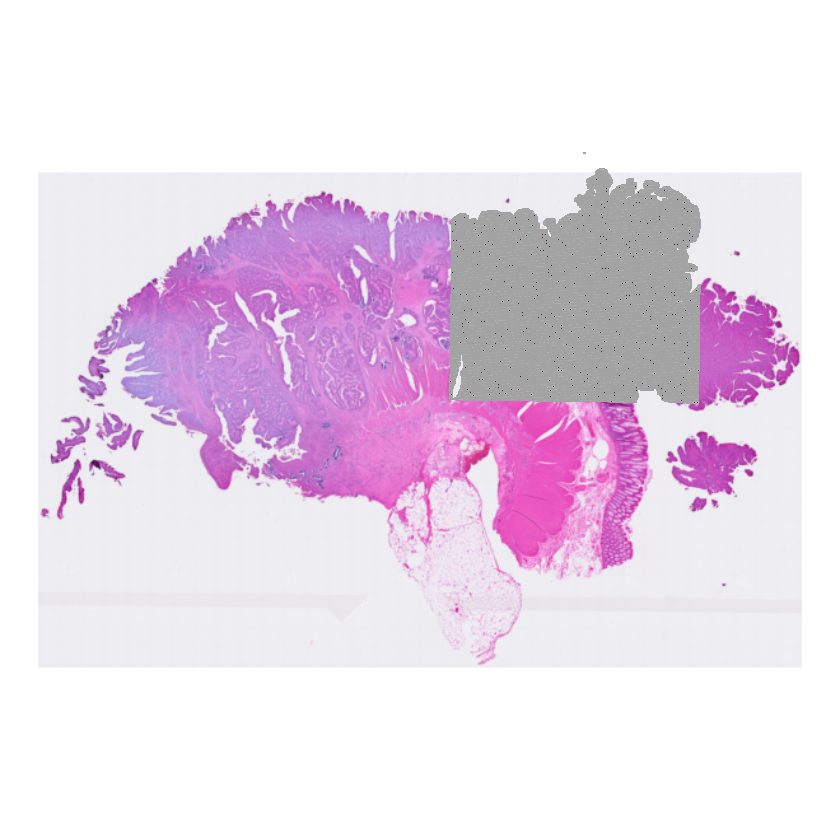

In [24]:
# Render the plot in the notebook
p_visium

We notice a massive, dense gray square overlaying only the right half of the pink H&E tissue image. The gray dots represent the 16µm spatial bins containing RNA transcripts. The sharp, square cutoff demonstrates the physical boundary of the Visium HD capture array (which is exactly 6.5x6.5mm). The tissue section was actually larger than the array, meaning we only captured transcriptomic data for the portion of the tissue sitting directly on top of the square.

Notice that inside the capture square, the gray dots perfectly trace the jagged edges of the tissue and don't bleed into the light background. This confirms that our `processing = "filtered"` argument successfully told the software to drop all empty background bins, saving us massive amounts of RAM!

### Xenium In Situ full-slide overview & alignment

Next, we generate an overview of the Xenium slide. Here, we cannot simply use the `plotVisium()` function because Visium relies on a fixed grid of bins overlaid on a standard flat H&E image, whereas Xenium captures true, irregularly shaped cell polygons over a complex, multi-channel Immunofluorescence (IF) image. Because of this complex geometry, we must use custom `ggplot2` mapping and the `Voyager` package (which is specifically designed for `SpatialFeatureExperiment` objects) to render the data.

Additionally, because the two machines use different physical coordinate origins (and tissue slices are often mounted at different angles), the raw Xenium coordinates will look rotated. To visually align them so we can easily select matching regions of interest later, we must manually flip and invert the Xenium axes in our plot.

In [25]:
# Extract the spatial coordinates (centroids of the cells) from the Xenium object
xy_xen <- as.data.frame(spatialCoords(sfe_xen))

# Plot the Xenium cells with artificially flipped coordinates
# By swapping X and Y, and negating them (-y, -x), we are mathematically 
# rotating and mirroring the spatial map to visually align with the Visium slide orientation.
p_xenium <- ggplot(xy_xen, aes(x = -y_centroid, y = -x_centroid)) +
  geom_point(size = 0.05, alpha = 0.3) + # Tiny, semi-transparent points due to millions of cells
  coord_fixed() +                        # Lock the aspect ratio so the tissue doesn't stretch
  theme_bw() +
  labs(x = "x", y = "y")

# Save the Xenium overview plot to our reports folder
ggsave(
  filename = data_path("prep_reports", "xenium_p2_crc_overview.png"),
  plot = p_xenium,
  width = 8,
  height = 7,
  dpi = 200
)

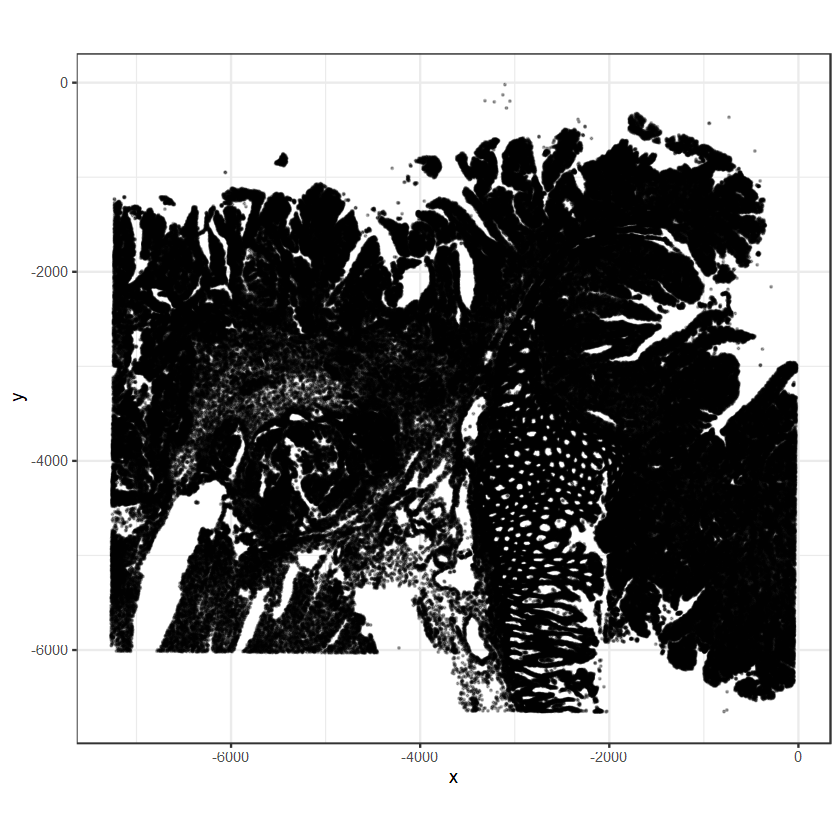

In [26]:
# Render the Xenium plot alone
p_xenium

To visually align them so we can select matching regions of interest later, we must manually flip and invert the Xenium axes. We will also plot the multiplexed immunofluorescence (IF) morphology image that Xenium uses for cell segmentation.

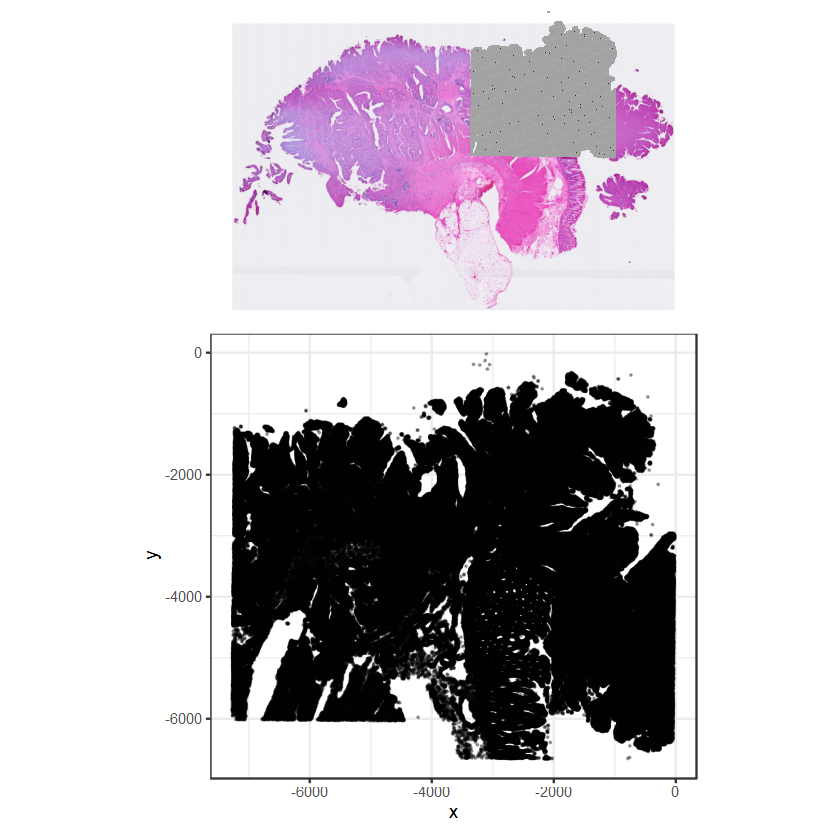

In [27]:
# Use 'patchwork' to plot them side-by-side to visually confirm they are aligned
library(patchwork)

# While the + or | operators place plots side-by-side horizontally, we can use 
# the / (divide) operator to stack them vertically!
#p_visium + p_xenium
p_visium / p_xenium

Take a close look at the black mass of cells in the Xenium plot (top). Thanks to the mathematical axis swapping and inversion (`x = -y` and `y = -x`) we applied in the code, the overall shape of the Xenium cells now perfectly matches the orientation of the tissue underneath the Visium HD capture square (bottom). This visually confirms that we are looking at two adjacent slices (serial sections) of the exact same tumor block, and they are now properly aligned on the screen.

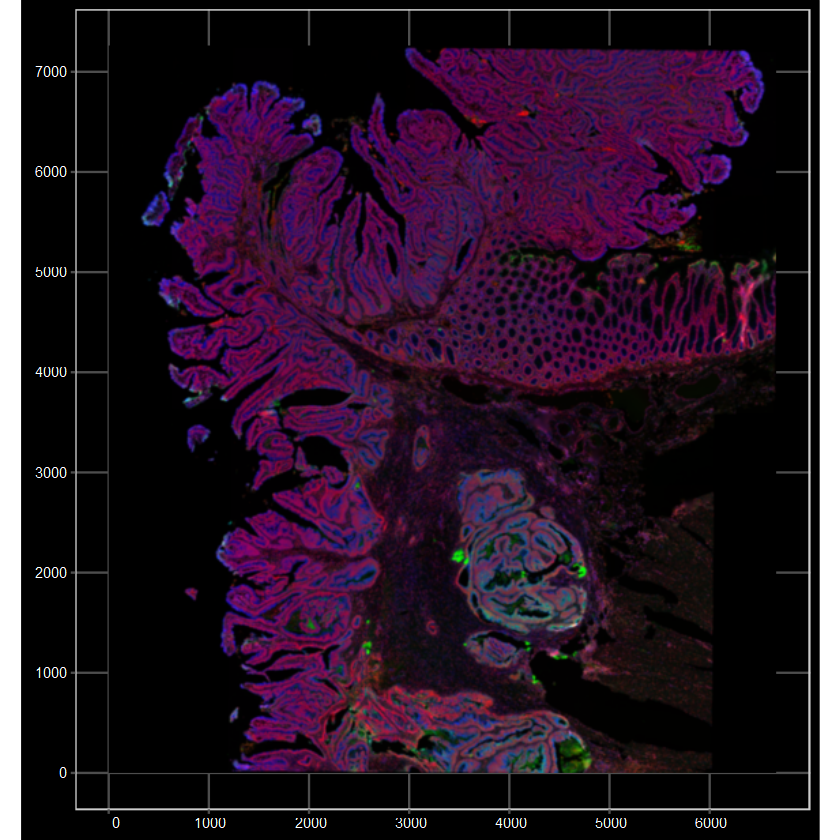

In [28]:
# Plot the actual Xenium morphology image (Immunofluorescence)
# The Xenium image contains 4 stains: DAPI (nucleus), ATP1A1/CD45/E-Cad (boundary), 
# 18S (interior), and AlphaSMA/Vimentin. Standard computer screens use RGB (Red, Green, 
# Blue), so we can only plot 3 channels  at a time. Here we select channels 1:3.
plotImage(
  sfe_xen, 
  image_id = "morphology_focus", 
  channel = 1:3, 
  show_axes = TRUE,
  dark = TRUE, 
  normalize_channels = TRUE
)

Unlike Visium HD, which uses a traditional brightfield H&E stain (the pink background), Xenium uses multiplexed **Immunofluorescence (IF)**. The dark background highlights specific fluorescent markers mapped to RGB channels (such as DAPI for blue nuclei, and E-Cadherin for cell boundaries). Notice how incredibly detailed the morphology is; we can clearly see the intricate folds of the colon crypts, the dense tumor areas, and the stromal boundaries. This specific fluorescent image is exactly what the Xenium onboard software used to physically draw the polygon boundaries around every single cell in the dataset.

### Subset approximately matching regions

With our overview plots generated, we can now define precise coordinate bounding boxes to crop our datasets.

For the Visium HD ROI, we base our starting coordinates on [*Orchestrating Spatially-Resolved Transcriptomics Analysis (OSTA)*](https://bioconductor.org/books/release/OSTA/), but expand the bounding box significantly to capture *richer tissue morphology* and reach our target of 10,000--20,000 bins (16µm). Because the Visium HTML reports lack visible spatial axes, these physical coordinates are typically found using the 10x Loupe Browser or by iteratively guessing using `spatialCoords` in R.

In [29]:
print(summary(spatialCoords(spe_hd)))

 pxl_col_in_fullres pxl_row_in_fullres
 Min.   :40607      Min.   :-1894     
 1st Qu.:47217      1st Qu.: 7845     
 Median :53647      Median :12777     
 Mean   :53204      Mean   :12651     
 3rd Qu.:59084      3rd Qu.:17554     
 Max.   :65248      Max.   :22675     


The raw coordinates in our dataset are based on the massive, full-resolution original tissue image (e.g., X = 58,000 pixels). However, to save memory, we imported a shrunk-down `lowres` version of the image. If we try to plot our raw coordinates directly onto this small image, they will plot entirely off the screen! We must multiply our coordinates by the 10x `scaleFactors` to physically shrink our bounding box so it matches the miniature image currently loaded in R.

In [30]:
# Define Initial Guesses for the ROIs

# Define the Visium HD ROI (Expanded from the OSTA baseline)
# Target: ~10,000 to 20,000 bins to balance morphology and computation time.
roi_visium <- c(
  xmin = 50000,
  xmax = 58000,
  ymin = 14500,
  ymax = 22000)

# (Note: Visium pixel coordinates must be scaled using scaleFactors!)
roi_visium_scaled <- roi_visium * scaleFactors(spe_hd)

For Xenium ROI, we select a spatial bounding box that is morphologically comparable to the Visium HD region. Because we used `flip = "none"` during import, the dataset retains its raw native orientation. We can easily find these raw coordinates by opening the downloaded `Xenium_V1_Human_Colon_Cancer_P2_CRC_Add_on_FFPE_analysis_summary.html` report—the interactive plots have built-in X/Y axes (in µm) that perfectly match R. Just remember that standard image coordinates place _Y=0 at the top_, meaning Y values increase as we move down the tissue.

In [31]:
# Define the morphologically matching Xenium ROI 
# (Coordinates pulled directly from the Xenium HTML analysis summary)
roi_xenium <- c(
  xmin = 2200,
  xmax = 4500,
  ymin = 2500,
  ymax = 4900)

In [32]:
# Inspect the Initial ROIs visually

# Load the Simple Features (sf) package to handle geometric bounding boxes
library(sf)

# Plot the Xenium IF image with our initial bounding box overlaid in white
p_xen <- plotImage(
  sfe_xen, 
  image_id = "morphology_focus", 
  channel = 1:3, 
  show_axes = TRUE, 
  dark = TRUE, 
  normalize_channels = TRUE
) +
  geom_sf(
    data = st_as_sfc(st_bbox(roi_xenium)), 
    fill = NA, 
    color = "white", 
    linewidth = 0.5)

Linking to GEOS 3.14.1, GDAL 3.12.1, PROJ 9.7.1; sf_use_s2() is TRUE



In [33]:
# Plot the Visium HD image with its initial bounding box overlaid.
p_vis <- plotVisium(spe_hd, zoom = TRUE, spots = FALSE) + 
  geom_rect(
    xmin = roi_visium_scaled["xmin"], 
    xmax = roi_visium_scaled["xmax"], 
    ymin = nrow(imgRaster(spe_hd)) - roi_visium_scaled["ymin"], 
    ymax = nrow(imgRaster(spe_hd)) - roi_visium_scaled["ymax"], 
    col = "white", linewidth = 0.5, fill = NA  )

In [34]:
options(repr.plot.width = 12, repr.plot.height = 6)

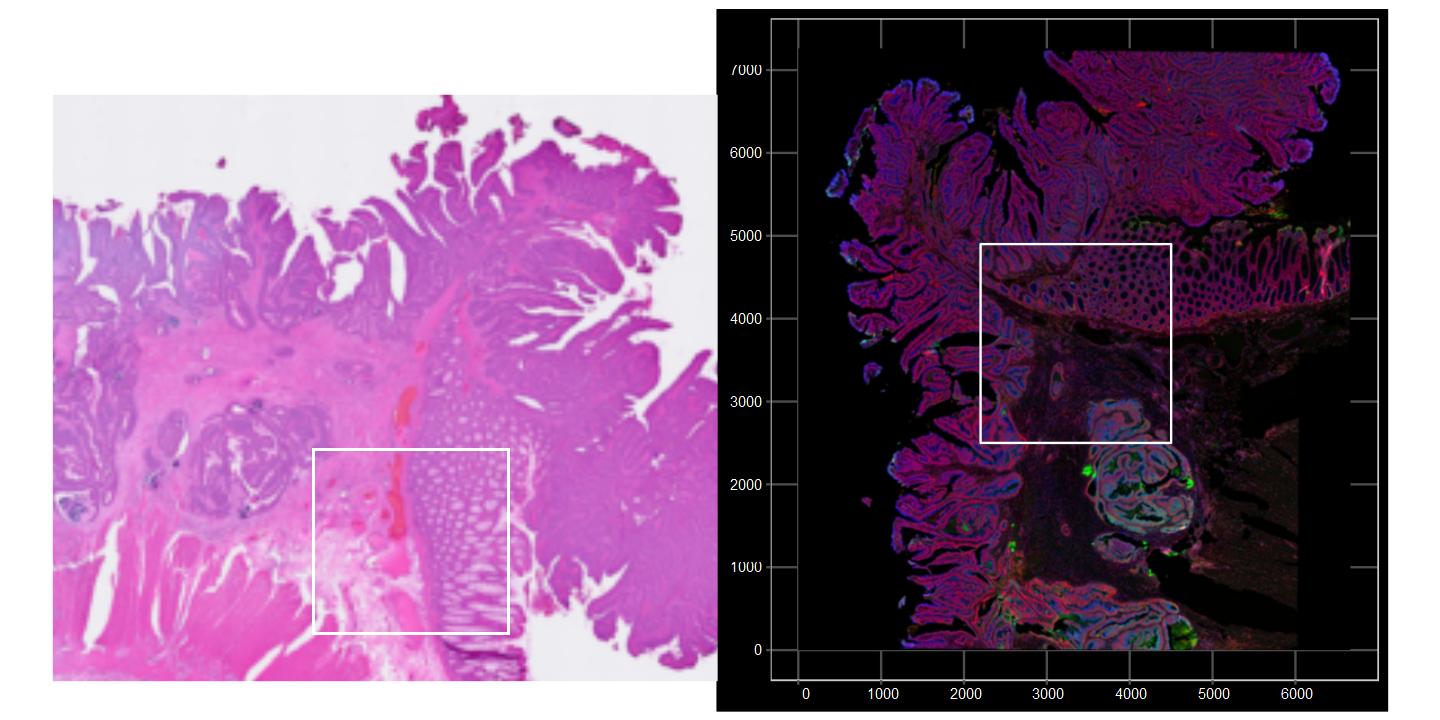

In [35]:
# Compare them side-by-side
p_vis + p_xen

### Adjusting the Visium ROI

Aligning serial sections by eye is difficult because the tissue slices are often mounted at different angles on their respective slides, meaning the images are rotated relative to each other. 

To overcome this rotation, we look for distinct *biological landmarks*. Notice two major features in the tissue:

1. The "honeycomb" field of dense circular crypts.
2. The large, isolated, circular glandular "swirl" structure.

* **In the Xenium plot (right):** Our white bounding box sits directly on the boundary *between* the dense crypt field (top right of the box) and the large swirl structure (bottom right).
* **In our initial Visium guess (left):** Our white box completely misses the large swirl structure and extends way too far down into the empty stroma/muscle layer.

To fix this, we will adjust the Visium coordinates (shifting the box upwards) so it perfectly frames that same boundary between the crypt field and the large swirl. The physical coordinates defined then are the finalized ROIs selected after visually inspecting the overview plots. By explicitly hardcoding them here, we ensure that the compact course datasets can be regenerated perfectly and reproducibly by anyone in the next notebooks.

In [36]:
# Adjust and Refine (Trial and Error)

# Let's shift the Visium ROI upwards (decreasing the Y minimum) to capture 
# the matching glandular structures seen in the Xenium box.
roi_visium_new <- c(
  xmin = 49000,
  xmax = 58000,
  ymin = 7500,  # Shifted significantly to match the morphology
  ymax = 16000
)

# Re-scale and re-plot the new Visium bounding box
roi_visium_scaled <- roi_visium_new * scaleFactors(spe_hd)
p_vis_new <- plotVisium(spe_hd, zoom = TRUE, spots = FALSE) + 
    geom_rect(
        xmin = roi_visium_scaled["xmin"], 
        xmax = roi_visium_scaled["xmax"], 
        ymin = nrow(imgRaster(spe_hd)) - roi_visium_scaled["ymin"], 
        ymax = nrow(imgRaster(spe_hd)) - roi_visium_scaled["ymax"], 
        col = "white", linewidth = 0.5, fill = NA)

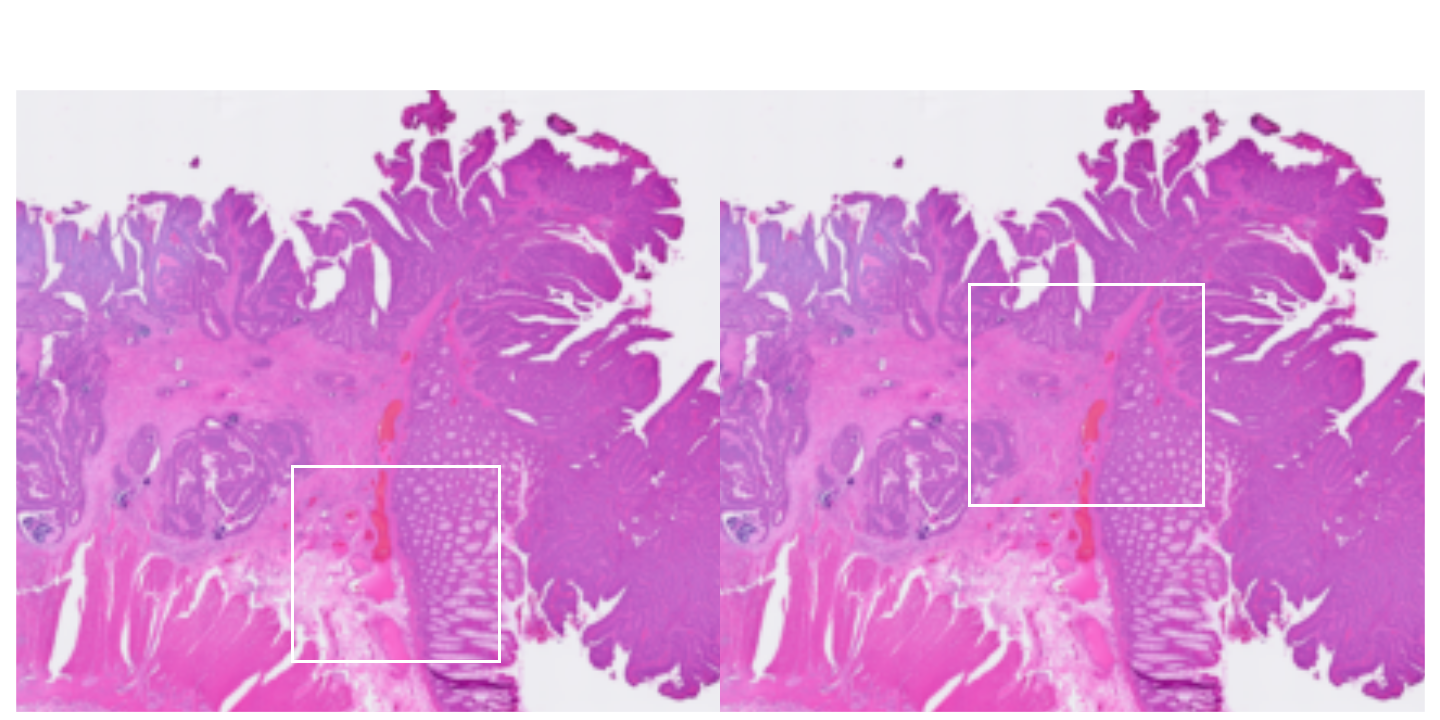

In [37]:
# Compare the old Visium guess vs the new Visium guess
p_vis + p_vis_new

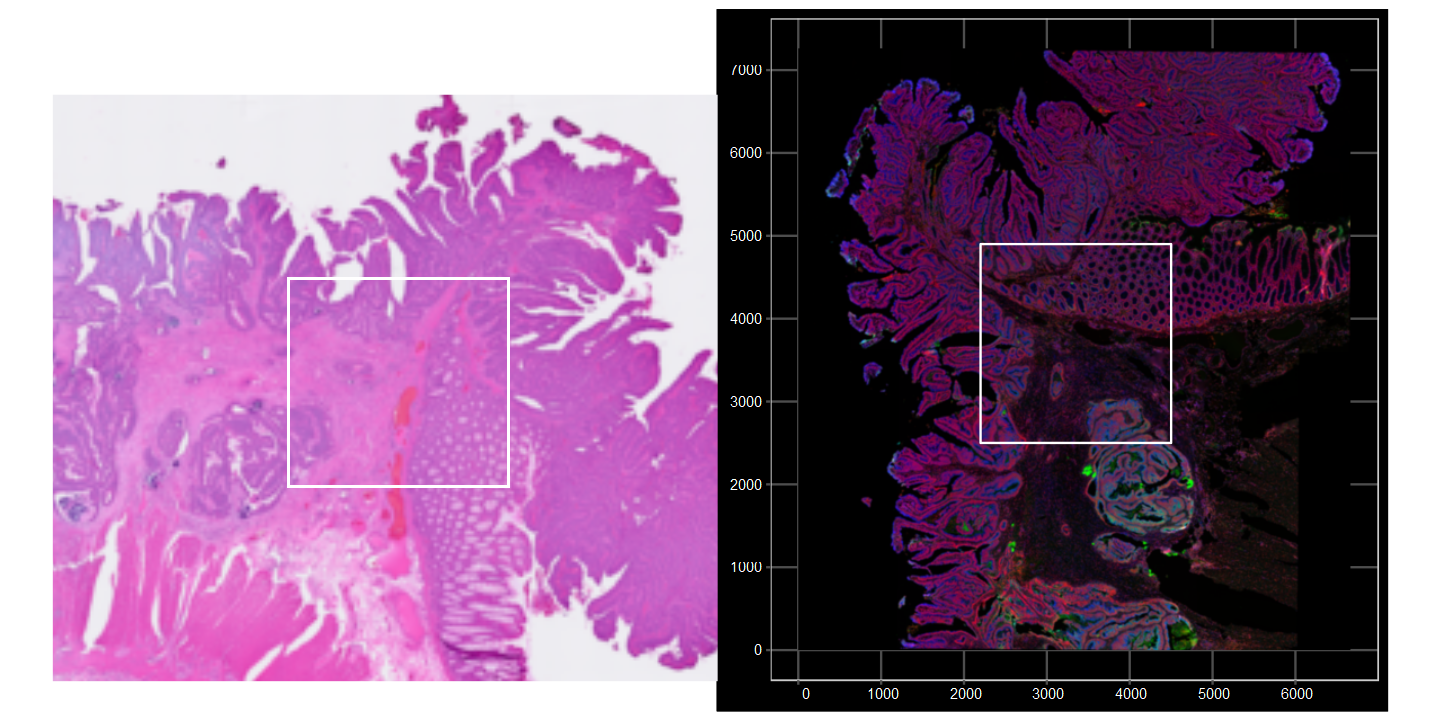

In [38]:
# Finally, compare our NEW Visium ROI with the Xenium ROI
p_vis_new + p_xen

## Crop and assemble final dataset

With our exact coordinate boundaries visually confirmed, the final phase of this preparation pipeline is to mathematically crop the objects and package them for distribution.

### Execute the spatial crop

We will now pass our finalized bounding boxes into the `subset_by_roi()` helper function. This function filters the raw spatial matrices, discarding any cells or transcriptomic bins that fall outside of our target area. By stripping away the majority of the surrounding tissue, we drastically reduce the RAM footprint of the `SpatialExperiment` and `SpatialFeatureExperiment` objects.

In [39]:
# Apply the subset function
# This helper function filters the raw coordinate matrix, dropping any 
# cells or bins that fall outside our specified bounding boxes.
spe_hd_p2_crc_sub <- subset_by_roi(spe_hd, roi_visium_new)
sfe_xen_p2_crc_sub <- subset_by_roi(sfe_xen, roi_xenium)

# Compare object dimensions
# Because a spatial crop only removes physical area, the total number of genes (rows) 
# remains exactly the same. Since only the number of bins/cells (columns) changes, 
# we can skip printing the full dim() and extract just ncol() to build a clean summary:
cat(
  "=== Spatial Cropping Summary ===\n",
  "Visium HD:\n",
  # format(..., big.mark = ",") add commas to the huge numbers
  "  Original: ", format(ncol(spe_hd), big.mark = ","), " bins\n",
  "  Cropped:  ", format(ncol(spe_hd_p2_crc_sub), big.mark = ","), " bins\n\n",
  "Xenium:\n",
  "  Original: ", format(ncol(sfe_xen), big.mark = ","), " cells\n",
  "  Cropped:  ", format(ncol(sfe_xen_p2_crc_sub), big.mark = ","), " cells\n",
  "================================\n"
)

=== Spatial Cropping Summary ===
 Visium HD:
   Original:  137,051  bins
   Cropped:   22,419  bins

 Xenium:
   Original:  340,837  cells
   Cropped:   52,569  cells


In [40]:
# QC Check 1: Ensure the Visium subset hits our target size (10k-20k bins)
# If it is too large, it will crash laptops; if too small, the biology is lost.
if (ncol(spe_hd_p2_crc_sub) < 10000 || ncol(spe_hd_p2_crc_sub) > 20000) {
  message(
    "The Visium HD subset contains ", ncol(spe_hd_p2_crc_sub),
    " bins. Consider adjusting roi_visium_new to keep the practical object ",
    "near 10,000-20,000 bins.")}

# QC Check 2: Ensure the Xenium subset actually captured data
# If 0 cells are returned, it means our coordinate bounding box was completely empty.
if (ncol(sfe_xen_p2_crc_sub) == 0) {
  stop(
    "The Xenium subset contains 0 cells. Check roi_xenium against ",
    "range(spatialCoords(sfe_xen)).")}

The Visium HD subset contains 22419 bins. Consider adjusting roi_visium_new to keep the practical object near 10,000-20,000 bins.



### Validate the cropped regions

Before we export these objects for the upcoming analyses, we must visually verify that our spatial subsetting worked perfectly. We will plot the newly cropped objects, ensuring that `zoom = TRUE` is enabled so the underlying tissue images are cropped to match our new boundaries.

In [41]:
# --------------------------------------------------------------------
# 1. VISIUM HD: Validate Morphology and Gene Expression
# --------------------------------------------------------------------

# Plot the newly cropped Visium H&E morphology
p_visium_sub <- plotVisium(
  spe_hd_p2_crc_sub, 
  spots = TRUE, 
  zoom = TRUE,       # Crops the underlying H&E image to match our new boundaries
  point_shape = 22,  # Keep the square shape
  point_size = 0.6   # Increase point size since we are now zoomed in
)

# Plot Visium gene expression to verify biological data integrity.
# We map 'PIGR', a classic epithelial marker. We should see high 
# expression (bright colors) directly overlapping the glandular structures
p_visium_pigr <- plotVisium(
  spe_hd_p2_crc_sub,
  annotate = "PIGR", 
  assay = "counts", 
  zoom = TRUE,
  point_size = 1,     # Increased to 1 so the expression colors clearly pop
  point_shape = 22
)


# --------------------------------------------------------------------
# 2. XENIUM: Validate Native Coordinate Geometry
# --------------------------------------------------------------------

# Extract the coordinates of the newly cropped Xenium subset
xy_xen_sub <- as.data.frame(spatialCoords(sfe_xen_p2_crc_sub))
names(xy_xen_sub)[1:2] <- c("x", "y")  # Rename for easier ggplotting

# Plot the cropped Xenium cells in their native orientation.
# Notice we do NOT mathematically flip the axes here. We want to see 
# the raw data exactly as it will be saved in our final course object.
p_xenium_sub <- ggplot(xy_xen_sub, aes(x = x, y = y)) +
  geom_point(size = 0.08, alpha = 0.4) +
  coord_fixed() +
  theme_bw() +
  labs(x = "x", y = "y")

Warning message in guide(title = annotate, order = 1, override.aes = list(col = NA, :
"Arguments in `...` must be used.
✖ Problematic argument:
• override.aes = list(col = NA, size = 3)
ℹ Did you misspell an argument name?"


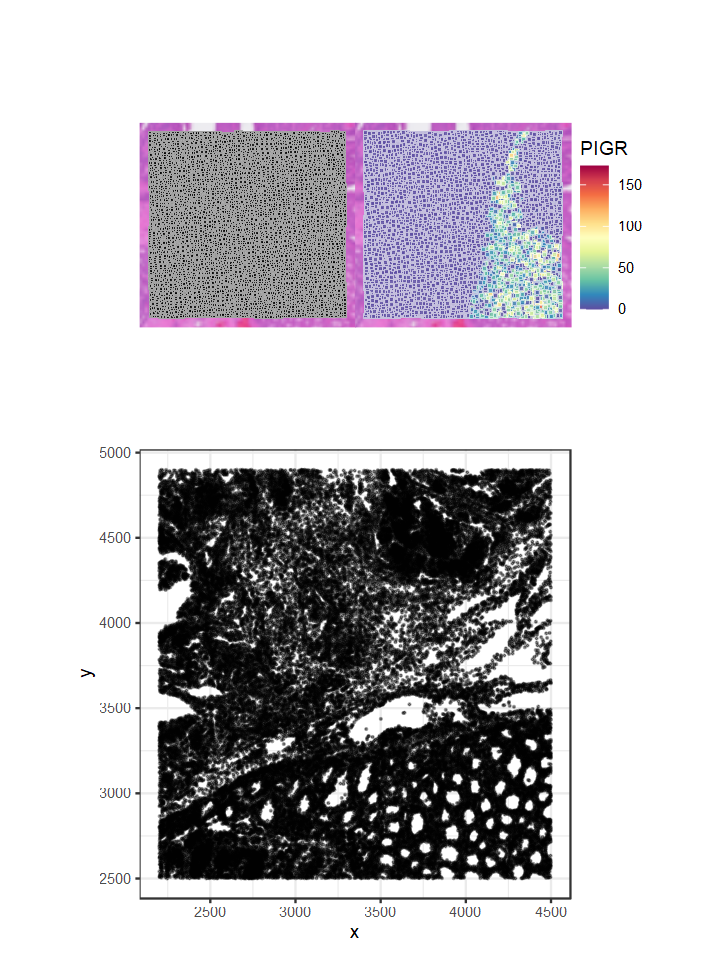

In [42]:
options(repr.plot.width = 6, repr.plot.height = 8)

# Render the plots using patchwork
# (Visium H&E next to Visium Expression) stacked on top of Xenium
(p_visium_sub | p_visium_pigr) / p_xenium_sub

### Exporting visual receipts

Finally, we save these high-resolution plots to our `prep_reports` folder. This provides a permanent, static visual record of the exact tissue regions we selected for the course. It allows us to review the morphology later without needing to re-load the massive R objects.

In [43]:
# Export Visual Receipts
ggsave(
  filename = data_path("prep_reports", "visium_hd_p2_crc_subset.png"), 
  plot = p_visium_sub, 
  width = 7, height = 6, dpi = 200)

ggsave(
  filename = data_path("prep_reports", "xenium_p2_crc_subset.png"), 
  plot = p_xenium_sub, 
  width = 7, height = 6, dpi = 200)

ggsave(
  filename = data_path("prep_reports", "visium_hd_p2_crc_subset_PIGR.png"), 
  plot = p_visium_pigr, 
  width = 7, height = 6, dpi = 200)

### Assemble compact files

The original, public 10x Genomics outputs are far too large for data distribution. We must assemble a compact, lightweight folder. In this final step, we pick and choose only the minimal necessary files (dropping massive, unused morphology TIFFs and raw, unfiltered matrices) and copy them into a clean distribution directory.

In [44]:
# Setup the Clean Distribution Directory
data_dir <- data_path("Human_Colon_Cancer_P2")

# Wipe the directory if it already exists, then build the fresh structure
unlink(data_dir, recursive = TRUE)
dir.create(data_dir, showWarnings = FALSE, recursive = TRUE)
dir.create(file.path(data_dir, "binned_outputs"), recursive = TRUE)
dir.create(file.path(data_dir, "xenium", "outs"), recursive = TRUE)
dir.create(file.path(data_dir, "chromium"), recursive = TRUE)
dir.create(file.path(data_dir, "reports"), recursive = TRUE)

#### Packaging Visium HD

A standard 10x Space Ranger output for Visium HD contains massive "raw" count matrices (which include millions of empty background bins) across three different resolution folders: 2µm, 8µm, and 16µm. Distributing the raw outputs would make the data download tens of gigabytes in size.

To solve this, the code below loops through all three bin sizes and extracts only the bare essentials:

1. **The Filtered Matrix (`filtered_feature_bc_matrix.h5`):** This matrix only contains bins that actually overlap the physical tissue, which drastically reduces the file size.
2. **The Spatial Folder (`spatial/`):** This folder contains the miniature H&E tissue images, scaling factors, and barcode coordinate lists. These are strictly required by R to physically map the gene expression back onto the tissue slide.

While our main exercises will focus on the 16µm bins to save laptop memory, copying these lightweight filtered files for the 2µm and 8µm resolutions allows us to explore the file structures of the higher resolutions without downloading gigabytes of raw data.

In [45]:
# Retain ONLY the filtered HDF5 matrix and spatial files for each bin size. 
# We drop the massive "raw" matrices. This keeps the folder tiny but still 
# allows TENxVisiumHD(..., processing = "filtered", format = "h5") to work perfectly.
for (bin in c("square_002um", "square_008um", "square_016um")) {
  source_bin <- file.path(visium_dir, "binned_outputs", bin)
  target_bin <- file.path(data_dir, "binned_outputs", bin)
  
  dir.create(target_bin, recursive = TRUE)
  dir.create(file.path(target_bin, "spatial"), recursive = TRUE)

  # Copy the filtered H5 matrix
  file.copy(
    from = file.path(source_bin, "filtered_feature_bc_matrix.h5"), 
    to = file.path(target_bin, "filtered_feature_bc_matrix.h5"), 
    overwrite = TRUE)

  # Copy the spatial images (tissue positions, scaling factors, etc.)
  file.copy(
    from = list.files(file.path(source_bin, "spatial"), full.names = TRUE), 
    to = file.path(target_bin, "spatial"), 
    overwrite = TRUE, 
    recursive = TRUE)}

#### Packaging Xenium In Situ

Similar to Visium, a raw Xenium output folder contains several gigabytes of data. Most of this weight comes from the massive multi-channel OME-TIFF morphology images and the raw subcellular transcript coordinate files. 

For the purposes of this course, we only need the segmented cells and their gene counts. The code below explicitly defines a `xenium_keep` list to extract only the absolute necessities:

1. **Configuration Files (`.json`, `.csv`, `.xenium`):** The metadata required by R to initialize and understand the object.
2. **The Count Matrix (`.h5`):** The cell-by-gene expression counts.
3. **Spatial Geometries (`.parquet`):** The physical coordinates of the cell and nucleus polygons. 

_Notice that we specifically include the `_sf.parquet` files. These are pre-processed "Simple Features" versions of the boundaries. Including these saves massive amounts of computation time, as it prevents the we' laptops from having to manually recalculate complex polygons from the raw boundary files during the data import._

In [46]:
# Retain only the minimum outputs needed to import the object and work with 
# cell/nucleus geometries. Crucially, we drop the giant OME-TIFF morphology images.
xenium_keep <- c(
  "experiment.xenium",
  "gene_panel.json",
  "metrics_summary.csv",
  "cell_feature_matrix.h5",
  "cells.parquet",
  "cell_boundaries.parquet",
  "nucleus_boundaries.parquet",
  "cell_boundaries_sf.parquet",     # Pre-processed Simple Features (sf) load faster!
  "nucleus_boundaries_sf.parquet"
)

# Only copy files if they actually exist in the raw outs folder
file.copy(
  from = file.path(
    xenium_outs, xenium_keep[file.exists(file.path(xenium_outs, xenium_keep))]), 
  to = file.path(data_dir, "xenium", "outs"), 
  overwrite = TRUE)

[1] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE

#### Packaging the single-cell reference and QC reports

To complete our dataset, we need to include two final pieces of supporting information: the single-cell reference and the interactive quality control (QC) reports.

1. **The Chromium Reference:** While spatial transcriptomics is incredibly powerful for mapping *where* cells are, it often relies on traditional single-cell RNA-seq (scRNA-seq) to definitively identify *what* those cells are. We copy the Chromium dataset in its entirety to serve as our high-quality transcriptomic "dictionary." In downstream notebooks, we will use this reference to computationally annotate the cell types inside our spatial objects (a process known as label transfer or deconvolution).
2. **The 10x HTML Reports:** Rather than calculating every basic QC metric from scratch in R, we extract the 10x interactive HTML summaries (`web_summary.html` and `analysis_summary.html`). Including these in the final folder allows us to easily explore global sequencing metrics, initial clustering, and tissue morphology directly in the web browsers.

In [47]:
# Package Chromium Reference & 10x HTML Reports
# Copy the Chromium scRNA-seq reference needed for annotation exercises
file.copy(
  from = data_path("raw", chromium_files), 
  to = file.path(data_dir, "chromium"), 
  overwrite = TRUE)

# Copy the specific HTML and CSV summary reports for inspection
file.copy(
  from = data_path("raw", visium_files[c("metrics", "web_summary")]), 
  to = file.path(data_dir, "reports"), 
  overwrite = TRUE)

file.copy(
  from = data_path("raw", xenium_files[["analysis_summary"]]), 
  to = file.path(data_dir, "reports"), 
  overwrite = TRUE)

[1] TRUE TRUE TRUE

[1] TRUE TRUE

[1] TRUE

#### Generating a data dictionary (README)

Providing an archive file full of complex spatial folders without context is never optimal. Therefore, we generate a localized `README.md` file that will live permanently inside the dataset folder, acting as a "Data Dictionary."

Notice that we do not type this text file manually; we generate it **programmatically** using R. By having our R script write the file, we can dynamically inject our bounding box variables (`roi_visium_new` and `roi_xenium`) directly into the text. This guarantees that the coordinates listed in the documentation will always perfectly match the coordinates used to crop the data.

In [48]:
# Create a README directly inside the folder so we understand what 
# files they are looking at and what coordinates were used to build them.
writeLines(
  c(
    "# Human Colon Cancer P2 Compact Dataset",
    "",
    "Compact input data prepared for spatial transcriptomics analysis.",
    "",
    "This folder is designed to be downloaded as `Human_Colon_Cancer_P2.tar.gz` and extracted inside the project `data/` directory, producing `data/Human_Colon_Cancer_P2/`.",
    "",
    "Contents:",
    "",
    "- `binned_outputs/`: trimmed Visium HD P2 CRC Space Ranger binned outputs. Upcoming analysis notebooks primarily use the 16 um filtered HDF5 matrix and spatial image files, while 2 um and 8 um folders are retained so we can inspect available bin sizes.",
    "- `xenium/outs/`: minimal Xenium P2 CRC output files required to import the object for spatial analysis. Preprocessed `*_sf.parquet` segmentation files are included when available so the object loads faster.",
    "- `chromium/`: Chromium Single Cell Flex aggregated count matrix and metadata files for downstream annotation steps.",
    "- `reports/`: selected 10x summary reports, including the Visium metrics CSV, Visium web summary HTML, and Xenium analysis summary HTML.",
    "",
    "Target Regions of Interest (ROIs) used in upcoming notebooks:",
    "",
    paste0("- Visium HD: ", paste(names(roi_visium_new), roi_visium_new, sep = "=", collapse = ", ")),
    paste0("- Xenium: ", paste(names(roi_xenium), roi_xenium, sep = "=", collapse = ", ")),
    "",
    "The Visium HD and Xenium datasets are serial sections. The selected ROIs are morphology-rich and practical for analysis, but are not exact same-cell or same-coordinate regions."
  ),
  con = file.path(data_dir, "README.md")
)

#### Final audit and distribution

As a final administrative step, we generate a `course_subset_summary.csv` file inside our `prep_reports` directory. This acts as an audit log, recording the exact row (gene) and column (cell/bin) dimensions of our three final data objects for future reference.

In [49]:
# Save a CSV listing the final row/column dimensions of all 3 course objects.
course_subset_summary <- data.frame(
  object = c("spe_hd_p2_crc_sub", "sfe_xen_p2_crc_sub", "sce_chromium"), 
  rows = c(nrow(spe_hd_p2_crc_sub), nrow(sfe_xen_p2_crc_sub), nrow(sce_chromium)), 
  columns = c(ncol(spe_hd_p2_crc_sub), ncol(sfe_xen_p2_crc_sub), ncol(sce_chromium)))

write.csv(
  course_subset_summary, 
  file = data_path("prep_reports", "course_subset_summary.csv"), 
  row.names = FALSE)

**What happens next?**

Our lightweight course dataset is now fully assembled. The compact `Human_Colon_Cancer_P2` folder we just built is sitting locally in our `data/` directory. For the remainder of this training course, we will point directly to this optimized folder, allowing us to immediately begin our spatial analyses in the upcoming notebooks.

## (Optional) Disk cleanup

Spatial transcriptomics datasets are massive. The original 10x Genomics archives and extracted folders we used to build this subset are likely taking up tens of gigabytes of disk space. 

Now that our lightweight course dataset is safely packaged, we can run the code below to delete the raw downloaded archives and extracted folders, recovering some hard drive space. 

*(Warning: We only run this if we are absolutely finished tuning the ROI coordinates! If we run this and want to change the crop later, we will have to wait for the massive files to re-download from the 10x servers).*

In [50]:
# Uncomment the lines below to delete the massive raw and extracted directories:

unlink(data_path("raw"), recursive = TRUE)
unlink(data_path("extracted"), recursive = TRUE)

message("Disk cleanup completed!")

Disk cleanup completed!



In [51]:
sessionInfo()

R version 4.6.1 (2026-06-24 ucrt)
Platform: x86_64-w64-mingw32/x64
Running under: Windows 11 x64 (build 26340)

Matrix products: default
  LAPACK version 3.12.1

locale:
[1] LC_COLLATE=French_France.utf8  LC_CTYPE=French_France.utf8   
[3] LC_MONETARY=French_France.utf8 LC_NUMERIC=C                  
[5] LC_TIME=French_France.utf8    

time zone: Europe/Berlin
tzcode source: internal

attached base packages:
[1] stats4    stats     graphics  grDevices datasets  utils     methods  
[8] base     

other attached packages:
 [1] sf_1.1-3                        patchwork_1.3.2                
 [3] Voyager_1.14.0                  ggspavis_1.18.1                
 [5] ggplot2_4.0.3                   VisiumIO_1.8.0                 
 [7] TENxIO_1.14.0                   SpatialFeatureExperiment_1.14.0
 [9] SpatialExperiment_1.22.0        DropletUtils_1.32.1            
[11] scuttle_1.22.0                  SingleCellExperiment_1.34.0    
[13] SummarizedExperiment_1.42.0     Biobase_2.72.0         